In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [32]:
df = pd.read_csv("C:/Users/kkrit/OneDrive/Documents/ML/archive (20)/exp7/Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [33]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(df.isnull().sum())
df = df.dropna()

CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


In [34]:
X = df[['Annual_Income', 'Spending_Score']]

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

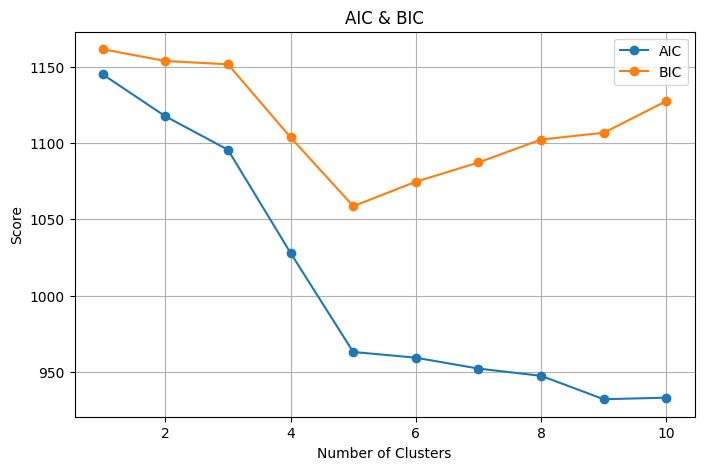

In [36]:
aic_values = []
bic_values = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    
    aic_values.append(gmm.aic(X_scaled))
    bic_values.append(gmm.bic(X_scaled))

plt.figure(figsize=(8,5))
plt.plot(K_range, aic_values, marker='o', label='AIC')
plt.plot(K_range, bic_values, marker='o', label='BIC')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("AIC & BIC")
plt.legend()
plt.grid()
plt.show()

In [37]:
k = 5 

gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X_scaled)

,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [38]:
probabilities = gmm.predict_proba(X_scaled)
labels = gmm.predict(X_scaled)

df['GMM_Cluster'] = labels

print("First 5 Probability Rows:\n", probabilities[:5])

First 5 Probability Rows:
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [39]:
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


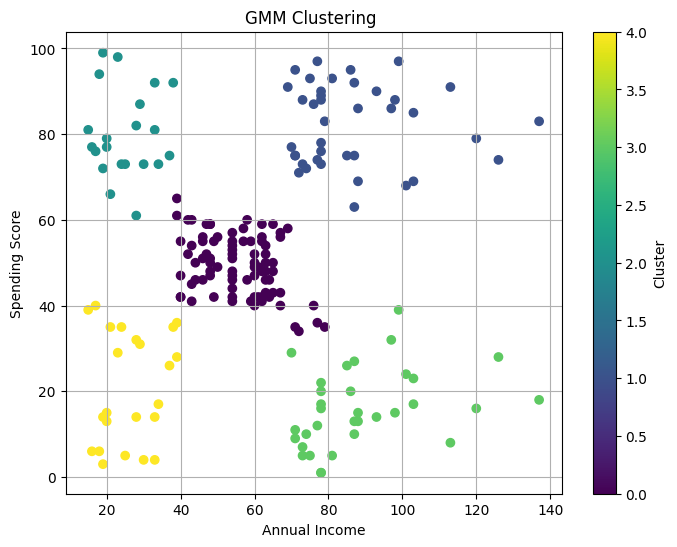

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=labels, cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM Clustering ")
plt.colorbar(label='Cluster')
plt.grid()
plt.show()

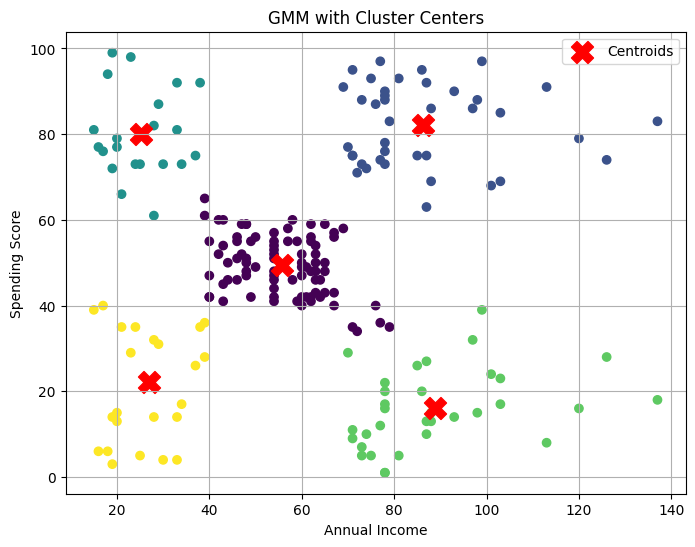

In [41]:
means = scaler.inverse_transform(gmm.means_)

plt.figure(figsize=(8,6))
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=labels, cmap='viridis')

plt.scatter(means[:,0], means[:,1],
            s=250, c='red', marker='X', label='Centroids')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM with Cluster Centers")
plt.legend()
plt.grid()
plt.show()

c:\Users\kkrit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


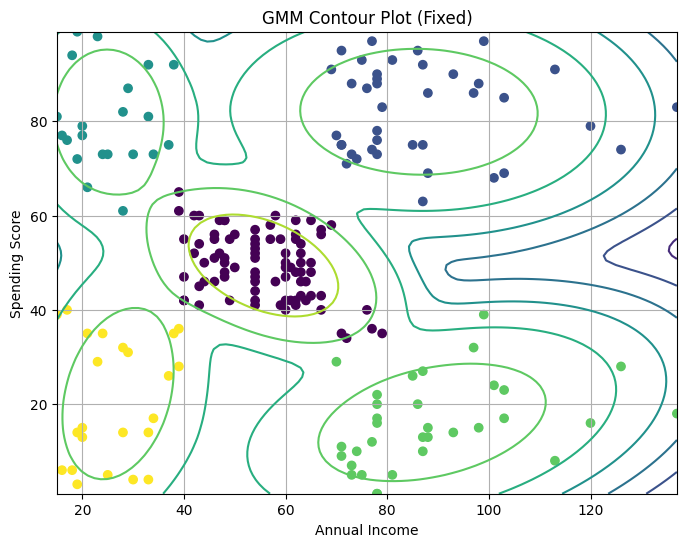

In [42]:
x = np.linspace(df['Annual_Income'].min(), df['Annual_Income'].max(), 100)
y = np.linspace(df['Spending_Score'].min(), df['Spending_Score'].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

grid = np.c_[X_grid.ravel(), Y_grid.ravel()]
grid_scaled = scaler.transform(grid)

Z = gmm.score_samples(grid_scaled)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(8,6))

plt.contour(X_grid, Y_grid, Z)
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=labels, cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("GMM Contour Plot (Fixed)")
plt.grid()
plt.show()

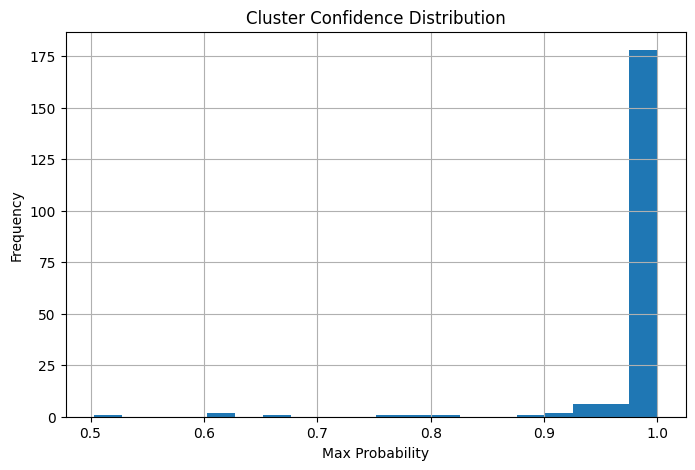

In [43]:
plt.figure(figsize=(8,5))

plt.hist(probabilities.max(axis=1), bins=20)

plt.title("Cluster Confidence Distribution")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.grid()
plt.show()

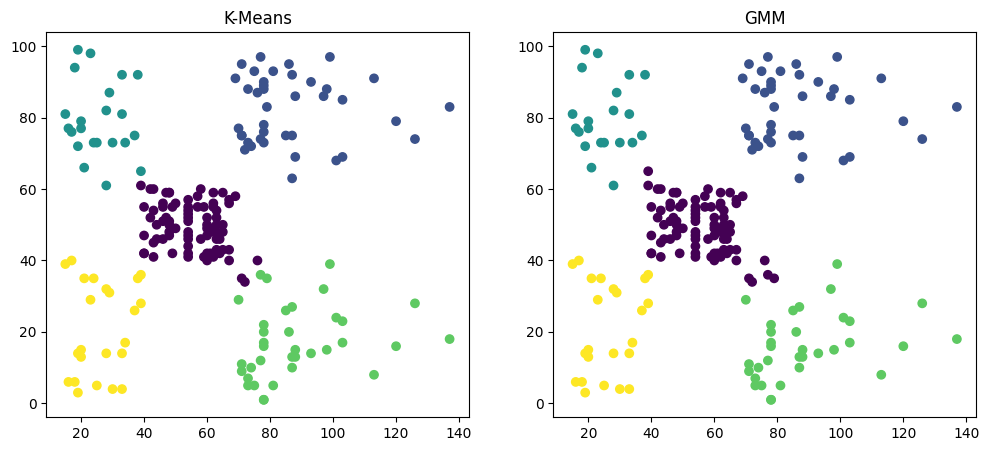

In [44]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=kmeans_labels, cmap='viridis')
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=labels, cmap='viridis')
plt.title("GMM")

plt.show()